In [69]:
using IonSim
using QuantumOptics
using PyPlot

In [ ]:
# ---------------------------------------------------------
# 1. Setup the Physical System
# ---------------------------------------------------------
# We need a higher Hilbert space dimension (N=20) to simulate displacements
# If N is too low, the wavepacket will "hit the wall" of the simulation array.
trap_freq = 1e6 # 1 MHz trap frequency
# mode = VibrationalMode(1, [0,0,1], δν=trap_freq, N=20) 
ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
mode_z.N = 10

# ---------------------------------------------------------
# 2. Define the Bichromatic Laser Field
# ---------------------------------------------------------
# To create the displacement, we need TWO lasers (or one laser with two tones).
# Both need to be parallel to the Z-axis (k=ẑ) to push the ion.

k_vec = (x̂ + ẑ) / √2
# k_vec = ẑ
ϵ_vec = (x̂ + ŷ) / √2
# ϵ_vec = ŷ

laser_intensity = 2e7 # Adjust this to push the ion faster/slower
# transition_λ = 729e-9 # Wavelength is REQUIRED to calculate the Lamb-Dicke parameter!
B_field = 1e-13
trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
transition_λ = transitionwavelength(ion, ("g", "e"), trap)


# Laser 1: Red Sideband (Detuned by -ω_m)
zeeman_offset = zeemanshift(ion, "e", B_field) - zeemanshift(ion, "g", B_field)
println("Zeeman Offset: ", zeeman_offset, " Hz")

# Laser 1: Red Sideband 
# Center on the Zeeman shifted carrier, then subtract the trap frequency
L_red = Laser(Δ = zeeman_offset - trap_freq, ϕ=0,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Laser 2: Blue Sideband 
# Center on the Zeeman shifted carrier, then add the trap frequency
L_blue = Laser(Δ = zeeman_offset + trap_freq, ϕ=π/2,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Create the Trap with both lasers shining on the ion

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

# ---------------------------------------------------------
# 3. Initialize the State
# ---------------------------------------------------------
# Start with Ion in |g> and Motion in |0>
mode = zmodes(trap)[1]
ψ_ion = normalize(-im * ion["g"]+  im * ion["e"])
# ψ_mode = fockstate(mode[1].basis, 0)
ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode


# ---------------------------------------------------------
# 4. Run the Simulation
# ---------------------------------------------------------
# Generate the Hamiltonian
h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
# Apply the two lasers for 15 microseconds
tspan = 0:0.5:50.0 
println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

# Get the final combined quantum state (Ion ⊗ Motion)
final_state = sol[end]

# ---------------------------------------------------------
# 5. Extract and Plot the Wigner Function
# ---------------------------------------------------------
# The state 'final_state' contains BOTH the ion and the motion.
# We must "trace out" (ignore) the ion's internal state to look only at the motion.
# In IonSim, the order is (Ion_Basis ⊗ Mode_Basis), so the mode is subsystem 2.
rho_motional = ptrace(final_state, 1)

# FIX: Convert IonSim's VibrationalMode basis to a standard QuantumOptics FockBasis
# We used N=20 for our simulation, so we create a FockBasis of the same size.
b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec)


Zeeman Offset: 0.0005611952854826817 Hz
Simulating bichromatic displacement...


81×81 Matrix{Float64}:
 1.60657e-6  2.68639e-6   4.40068e-6   …  9.90074e-7   6.28119e-7
 2.6869e-6   4.46332e-6   7.26271e-6      1.5561e-6    9.99468e-7
 4.40239e-6  7.26417e-6   1.17402e-5      2.38842e-6   1.55415e-6
 7.06723e-6  1.15823e-5   1.85906e-5      3.57982e-6   2.36161e-6
 1.11166e-5  1.80935e-5   2.88399e-5      5.2391e-6    3.50682e-6
 1.71353e-5  2.76954e-5   4.38344e-5   …  7.48615e-6   5.08862e-6
 2.58846e-5  4.15416e-5   6.52816e-5      1.04428e-5   7.2153e-6
 3.83228e-5  6.10633e-5   9.52691e-5      1.4219e-5    9.9967e-6
 5.56111e-5  8.79677e-5   0.000136246     1.88943e-5   1.35324e-5
 7.91003e-5  0.000124203  0.000190952     2.44962e-5   1.78962e-5
 ⋮                                     ⋱               ⋮
 1.29086e-5  1.82456e-5   2.49852e-5      0.000374908  0.000232097
 9.59052e-6  1.3799e-5    1.92668e-5      0.000256584  0.000157769
 6.96808e-6  1.01957e-5   1.44977e-5      0.000172014  0.000105066
 4.95044e-6  7.35967e-6   1.06461e-5   …  0.000112959  6.8545

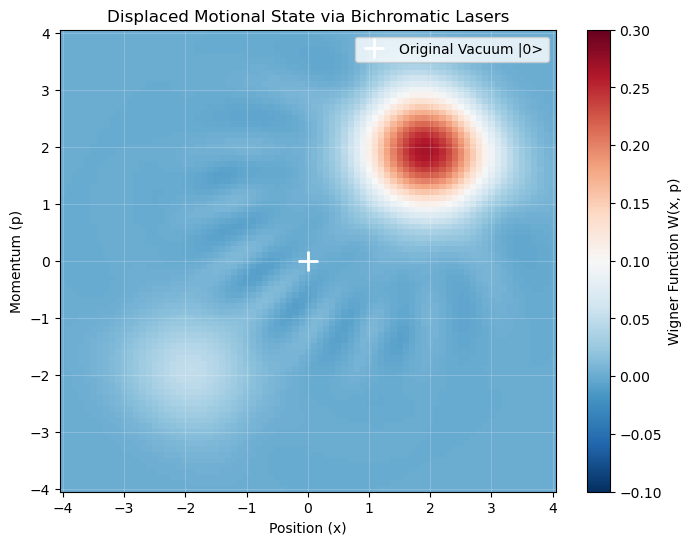

In [71]:
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


In [72]:
# Laser 1: Red Sideband 
# Center on the Zeeman shifted carrier, then subtract the trap frequency
L_red = Laser(Δ = zeeman_offset - trap_freq, ϕ=0,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Laser 2: Blue Sideband 
# Center on the Zeeman shifted carrier, then add the trap frequency
L_blue = Laser(Δ = zeeman_offset + trap_freq, ϕ=0,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Create the Trap with both lasers shining on the ion

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])



# ---------------------------------------------------------
# 4. Run the Simulation
# ---------------------------------------------------------
# Generate the Hamiltonian
h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
# Apply the two lasers for 15 microseconds
tspan = 0:0.5:5.0 
println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, final_state, h)

# Get the final combined quantum state (Ion ⊗ Motion)
final_state = sol[end]

# ---------------------------------------------------------
# 5. Extract and Plot the Wigner Function
# ---------------------------------------------------------
# The state 'final_state' contains BOTH the ion and the motion.
# We must "trace out" (ignore) the ion's internal state to look only at the motion.
# In IonSim, the order is (Ion_Basis ⊗ Mode_Basis), so the mode is subsystem 2.
rho_motional = ptrace(final_state, 1)

# FIX: Convert IonSim's VibrationalMode basis to a standard QuantumOptics FockBasis
# We used N=20 for our simulation, so we create a FockBasis of the same size.
b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec)


Simulating bichromatic displacement...


81×81 Matrix{Float64}:
 2.92834e-6   4.89195e-6   8.00553e-6   …  1.82542e-6   1.15949e-6
 4.86573e-6   8.07136e-6   1.31139e-5      2.8708e-6    1.8462e-6
 7.91698e-6   1.30386e-5   2.10295e-5      4.4107e-6    2.87366e-6
 1.26152e-5   2.06239e-5   3.30152e-5      6.62033e-6   4.37279e-6
 1.96877e-5   3.19455e-5   5.07498e-5      9.70775e-6   6.50533e-6
 3.00956e-5   4.84606e-5   7.63889e-5   …  1.39066e-5   9.46218e-6
 4.50669e-5   7.20032e-5   0.000112602     1.94614e-5   1.34569e-5
 6.61156e-5   0.000104795  0.000162566     2.66052e-5   1.87132e-5
 9.50353e-5   0.000149416  0.00022989      3.55274e-5   2.54456e-5
 0.000133858  0.000208722  0.000318467     4.6336e-5    3.38332e-5
 ⋮                                      ⋱               ⋮
 3.35908e-5   4.86359e-5   6.838e-5        0.000617894  0.000385746
 2.46105e-5   3.61944e-5   5.17551e-5      0.00042344   0.000262452
 1.76466e-5   2.63418e-5   3.82747e-5      0.000284338  0.000174993
 1.23811e-5   1.87459e-5   2.76548e-5   …  0.0

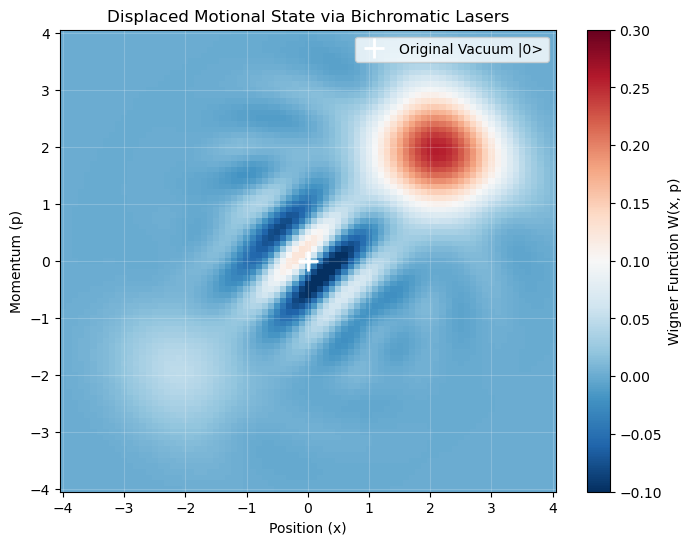

In [73]:
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


In [74]:
# Laser 1: Red Sideband 
# Center on the Zeeman shifted carrier, then subtract the trap frequency
L_red = Laser(Δ = zeeman_offset - trap_freq, ϕ=0,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Laser 2: Blue Sideband 
# Center on the Zeeman shifted carrier, then add the trap frequency
L_blue = Laser(Δ = zeeman_offset + trap_freq, ϕ=0,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Create the Trap with both lasers shining on the ion

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])



# ---------------------------------------------------------
# 4. Run the Simulation
# ---------------------------------------------------------
# Generate the Hamiltonian
h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
# Apply the two lasers for 15 microseconds
tspan = 0:0.5:10.0 
println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, final_state, h)

# Get the final combined quantum state (Ion ⊗ Motion)
final_state = sol[end]

# ---------------------------------------------------------
# 5. Extract and Plot the Wigner Function
# ---------------------------------------------------------
# The state 'final_state' contains BOTH the ion and the motion.
# We must "trace out" (ignore) the ion's internal state to look only at the motion.
# In IonSim, the order is (Ion_Basis ⊗ Mode_Basis), so the mode is subsystem 2.
rho_motional = ptrace(final_state, 1)

# FIX: Convert IonSim's VibrationalMode basis to a standard QuantumOptics FockBasis
# We used N=20 for our simulation, so we create a FockBasis of the same size.
b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec)


Simulating bichromatic displacement...


81×81 Matrix{Float64}:
 7.85472e-6   1.29053e-5   2.07535e-5   …  8.35063e-6   5.25854e-6
 1.30314e-5   2.12428e-5   3.38854e-5      1.33012e-5   8.4732e-6
 2.11843e-5   3.4257e-5    5.41949e-5      2.07082e-5   1.33527e-5
 3.37498e-5   5.41325e-5   8.49193e-5      3.15131e-5   2.05807e-5
 5.27034e-5   8.38327e-5   0.000130389     4.68759e-5   3.10282e-5
 8.06848e-5   0.000127261  0.000196219  …  6.81606e-5   4.57614e-5
 0.000121118  0.000189403  0.000289467     9.68849e-5   6.60282e-5
 0.000178305  0.000276419  0.000418691     0.000134626  9.32163e-5
 0.000257476  0.000395654  0.000593899     0.000182879  0.000128775
 0.000364756  0.000555532  0.000826291     0.00024286   0.0001741
 ⋮                                      ⋱               ⋮
 0.000207638  0.000306556  0.000440248     0.0016601    0.00105782
 0.000150335  0.000225106  0.000328195     0.00114793   0.000725287
 0.000106551  0.000161713  0.000239187     0.000778151  0.000487575
 7.39132e-5   0.000113636  0.000170398  …  0.00

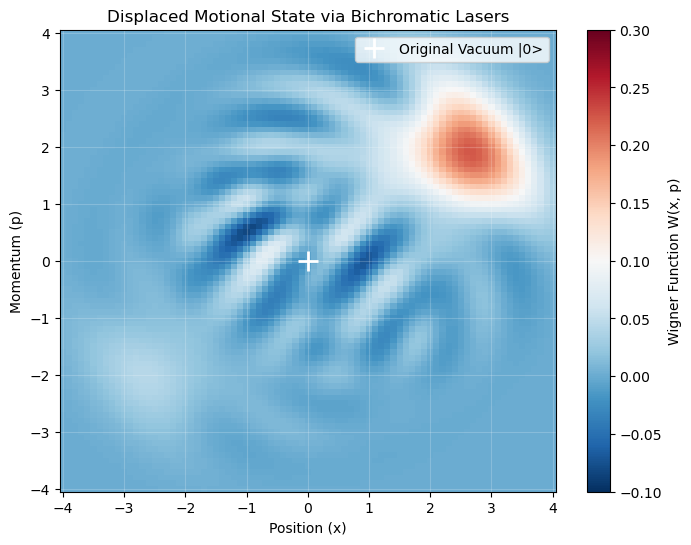

In [75]:
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


In [76]:
# Laser 1: Red Sideband 
# Center on the Zeeman shifted carrier, then subtract the trap frequency
L_red = Laser(Δ = zeeman_offset - trap_freq, ϕ=0,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Laser 2: Blue Sideband 
# Center on the Zeeman shifted carrier, then add the trap frequency
L_blue = Laser(Δ = zeeman_offset + trap_freq, ϕ=0,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Create the Trap with both lasers shining on the ion

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])



# ---------------------------------------------------------
# 4. Run the Simulation
# ---------------------------------------------------------
# Generate the Hamiltonian
h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
# Apply the two lasers for 15 microseconds
tspan = 0:0.5:15.0 
println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, final_state, h)

# Get the final combined quantum state (Ion ⊗ Motion)
final_state = sol[end]

# ---------------------------------------------------------
# 5. Extract and Plot the Wigner Function
# ---------------------------------------------------------
# The state 'final_state' contains BOTH the ion and the motion.
# We must "trace out" (ignore) the ion's internal state to look only at the motion.
# In IonSim, the order is (Ion_Basis ⊗ Mode_Basis), so the mode is subsystem 2.
rho_motional = ptrace(final_state, 1)

# FIX: Convert IonSim's VibrationalMode basis to a standard QuantumOptics FockBasis
# We used N=20 for our simulation, so we create a FockBasis of the same size.
b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec)


Simulating bichromatic displacement...


81×81 Matrix{Float64}:
 3.13929e-5   5.0749e-5    8.02448e-5   …  4.44059e-5   2.78603e-5
 5.13457e-5   8.22231e-5   0.00012874      7.10952e-5   4.50991e-5
 8.22252e-5   0.000130392  0.000202091     0.000111306  7.14253e-5
 0.000128944  0.000202424  0.000310442     0.000170413  0.000110684
 0.000198045  0.000307679  0.000466748     0.000255173  0.000167851
 0.000297971  0.000457967  0.00068695   …  0.000373728  0.000249128
 0.000439252  0.00066766   0.000989898     0.000535441  0.000361951
 0.000634566  0.000953567  0.0013969       0.000750509  0.00051485
 0.000898588  0.0013345    0.00193084      0.00102931   0.000717131
 0.00124758   0.00183046   0.00261478      0.0013815    0.000978351
 ⋮                                      ⋱               ⋮
 0.00138949   0.0020747    0.00301606      0.00443406   0.00289997
 0.000994444  0.00150415   0.00221692      0.00311831   0.00201853
 0.000696939  0.00106733   0.00159396      0.00214944   0.00137744
 0.000478209  0.000741145  0.00112089   … 

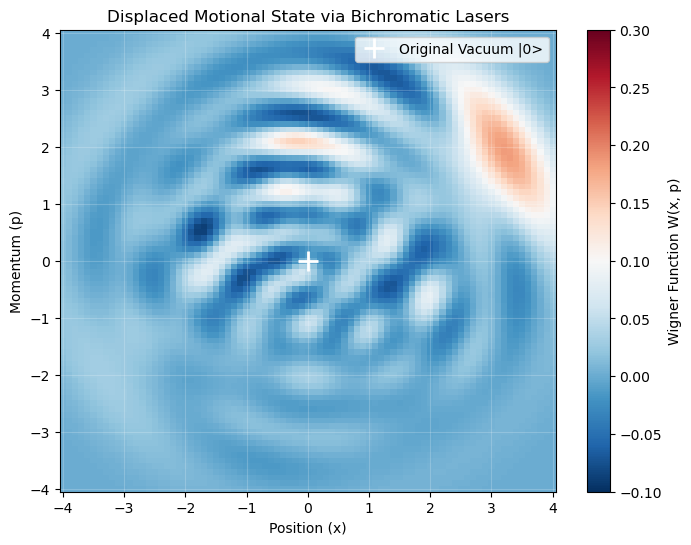

In [77]:
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


In [78]:
print(rho_fock)

Operator(dim=11x11)
  basis: Fock(cutoff=10)
    0.0236659+0.0im           0.0223514-0.00735657im    0.0262409-0.00734805im  -0.000320257-0.00476955im   0.0239709-0.00264829im    0.0211747+0.0137363im   0.00238817-0.023081im     0.0203179-0.0362352im   -0.010003+0.00468215im  -0.0400142+0.0258636im    0.014922+0.0189119im
    0.0223514+0.00735657im    0.0524818+0.0im            0.040465+0.00743265im     0.0317659-0.0278799im    0.0287843-0.0313984im   -0.00642313+0.0076568im   -0.0370513+0.00912577im   0.0409863+0.0143396im   0.0214299+0.0177369im   -0.0293471-0.0398304im   0.0333178-0.0442083im
    0.0262409+0.00734805im     0.040465-0.00743265im    0.0388772+0.0im            0.0102404-0.0226456im     0.022085-0.0133741im     0.0064672+0.0210585im  -0.00514618-0.00101486im   0.0476594-0.0166605im  0.00585808+0.00274165im  -0.0558793-0.0111382im  0.00798134-0.0104895im
 -0.000320257+0.00476955im    0.0317659+0.0278799im     0.0102404+0.0226456im      0.0517561+0.0im          0.0348939-

In [79]:
using LinearAlgebra
using QuantumOptics

"""
Calculates the Quantum Fisher Information and Cramér-Rao Bound 
for a parameter alpha. Automatically handles both pure states (Ket) 
and mixed states (Operator).
"""
function calculate_qcrb(state, state_perturbed, d_alpha::Float64; tol=1e-10)
    
    # 1. Promote pure states (Ket) to density matrices
    rho1 = isa(state, Ket) ? dm(state) : state
    rho2 = isa(state_perturbed, Ket) ? dm(state_perturbed) : state_perturbed
    
    # 2. Ensure they are in dense matrix format so we can access .data
    rho_dense = dense(rho1)
    rho_pert_dense = dense(rho2)

    # 3. Calculate the derivative of the density matrix via finite difference
    drho = (rho_pert_dense - rho_dense) / d_alpha
    
    # 4. Diagonalize the base density matrix
    λ, V = eigen(rho_dense.data)
    
    qfi = 0.0
    n = length(λ)
    
    # 5. Compute the Bures metric sum for Quantum Fisher Information
    for i in 1:n
        for j in 1:n
            if real(λ[i] + λ[j]) > tol
                # Project drho into the eigenbasis: <i | drho | j>
                drho_ij = dot(V[:, i], drho.data * V[:, j])
                
                # Add to the QFI sum
                qfi += 2 * (abs(drho_ij)^2) / real(λ[i] + λ[j])
            end
        end
    end
    
    # 6. The Cramér-Rao Bound is the inverse of the QFI
    qcrb = qfi > 0 ? 1.0 / qfi : Inf
    
    return qfi, qcrb
end

calculate_qcrb

In [80]:
# Example loop for Protocol 1 Finite Difference
t_base = 10.0
dt = 0.001
t_perturbed = t_base + dt

# Run simulation to t_base
tout1, sol1 = timeevolution.schroedinger_dynamic([0.0, t_base], ψ_initial, h)
state_base = sol1[end] # This is a Ket

# Run simulation to t_perturbed
tout2, sol2 = timeevolution.schroedinger_dynamic([0.0, t_perturbed], ψ_initial, h)
state_perturbed = sol2[end] # This is a Ket

# Calculate QCRB! 
# The function will now automatically convert your Kets to DenseOperators.
qfi, qcrb = calculate_qcrb(state_base, state_perturbed, dt)

println("Quantum Fisher Information: ", qfi)
println("Quantum Cramér-Rao Bound: ", qcrb)

Quantum Fisher Information: 2.404948642373002
Quantum Cramér-Rao Bound: 0.4158092952094327


In [81]:
ψ_mode = fockstate(mode, 1)
ψ_initial = ψ_ion ⊗ ψ_mode

Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.0e6, axis=ẑ, N=10)]
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 - 0.7071067811865475im
 0.0 + 0.7071067811865475im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
     ⋮
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im

In [82]:
# Example loop for Protocol 1 Finite Difference
t_base = 10.0
dt = 0.001
t_perturbed = t_base + dt

# Run simulation to t_base
tout1, sol1 = timeevolution.schroedinger_dynamic([0.0, t_base], ψ_initial, h)
state_base = sol1[end] # This is a Ket

# Run simulation to t_perturbed
tout2, sol2 = timeevolution.schroedinger_dynamic([0.0, t_perturbed], ψ_initial, h)
state_perturbed = sol2[end] # This is a Ket

# Calculate QCRB! 
# The function will now automatically convert your Kets to DenseOperators.
qfi, qcrb = calculate_qcrb(state_base, state_perturbed, dt)

println("Quantum Fisher Information: ", qfi)
println("Quantum Cramér-Rao Bound: ", qcrb)

Quantum Fisher Information: 4.850390120590387
Quantum Cramér-Rao Bound: 0.20616898334731895


In [91]:
# Example loop to plot QCRB over time (displacement)
t_max = 10.0
dt = 0.001
time_steps = 1:1:t_max # Adjust step size for plotting resolution


states = 0:1:5


fig = figure(figsize=(8, 6))

qcrb_matrix = Float64[5][]

for n in states
    qcrb_values = Float64[]
ψ_mode = fockstate(mode, n)
ψ_initial = ψ_ion ⊗ ψ_mode
for t in time_steps
    # Run simulation to current time t
    tout1, sol1 = timeevolution.schroedinger_dynamic([0.0, t], ψ_initial, h)
    state_base = sol1[end] 
    
    # Run simulation to slightly perturbed time t + dt
    tout2, sol2 = timeevolution.schroedinger_dynamic([0.0, t + dt], ψ_initial, h)
    state_perturbed = sol2[end] 
    
    # Calculate QCRB
    qfi, qcrb = calculate_qcrb(state_base, state_perturbed, dt)
    push!(qcrb_values, qcrb)
    qcrb_matrix[n+1, t] =  qcrb
end


PyPlot.plot(time_steps, qcrb_values, label="Protocol 1: Ideal Vacuum", linewidth=2.5, linestyle="-")


# Formatting for thesis presentation
PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("Quantum Cramér-Rao Bound (Minimum Variance)", fontsize=12)
PyPlot.title("Metrological Limits of Ca-40 Phononic Cat State Sensor", fontsize=14)
PyPlot.legend(loc="upper left", fontsize=11)
PyPlot.grid(color="gray", alpha=0.3, linestyle=":")

end

display(fig)

MethodError: MethodError: no method matching setindex!(::Float64, ::Float64, ::Int64, ::Float64)
The function `setindex!` exists, but no method is defined for this combination of argument types.
Are you trying to index into an array? For multi-dimensional arrays, separate the indices with commas: a[1, 2] rather than a[1][2]

Simulating Fock State |0⟩...
Simulating Fock State |1⟩...
Simulating Fock State |2⟩...
Simulating Fock State |3⟩...
Simulating Fock State |4⟩...
Simulating Fock State |5⟩...


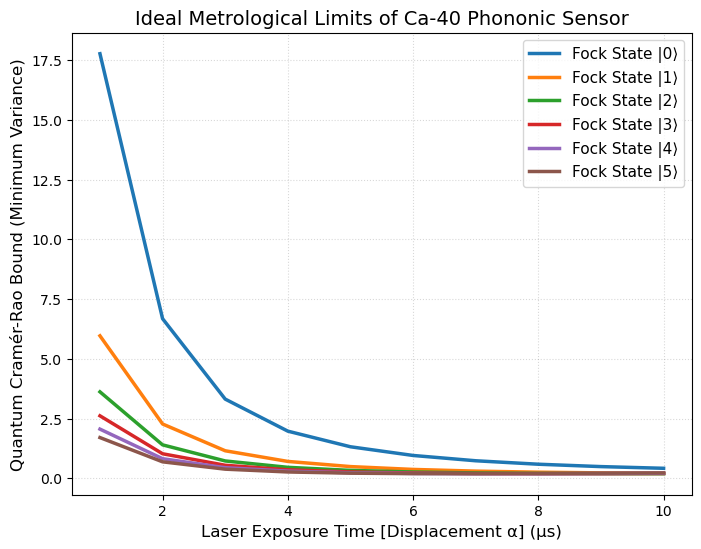

In [92]:
# Example loop to plot QCRB over time (displacement)
t_max = 10.0
dt = 0.001
time_steps = 1.0:1.0:t_max # Use explicit floats for the time span

states = 0:5 # Test Fock states |0> through |5>

fig = figure(figsize=(8, 6))

# Safely pre-allocate a 2D matrix of zeros
# Rows = number of Fock states, Columns = number of time steps
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    # Initialize state
    ψ_mode = fockstate(mode, n)
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    println("Simulating Fock State |", n, "⟩...")
    
    for (j, t) in enumerate(time_steps)
        # Run simulation to current time t
        tout1, sol1 = timeevolution.schroedinger_dynamic([0.0, t], ψ_initial, h)
        state_base = sol1[end] 
        
        # Run simulation to slightly perturbed time t + dt
        tout2, sol2 = timeevolution.schroedinger_dynamic([0.0, t + dt], ψ_initial, h)
        state_perturbed = sol2[end] 
        
        # Calculate QCRB
        qfi, qcrb = calculate_qcrb(state_base, state_perturbed, dt)
        push!(qcrb_values, qcrb)
        
        # Save to matrix using the safe integer indices (i, j)
        qcrb_matrix[i, j] = qcrb
    end

    # Plot the line for this specific Fock state immediately
    # This ensures the legend correctly labels |0>, |1>, etc.
    PyPlot.plot(time_steps, qcrb_values, label="Fock State |$n⟩", linewidth=2.5, linestyle="-")
end

# Formatting for thesis presentation
PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("Quantum Cramér-Rao Bound (Minimum Variance)", fontsize=12)
PyPlot.title("Ideal Metrological Limits of Ca-40 Phononic Sensor", fontsize=14)
PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(color="gray", alpha=0.3, linestyle=":")

display(fig)

In [99]:
print(qcrb_matrix[1,:])

[17.77343874455764, 6.6792930505160255, 3.3124325791322606, 1.970537026825896, 1.3167307182656516, 0.9528065033542809, 0.7306997785243594, 0.5858252739074719, 0.48651595396515157, 0.4158092952094327]

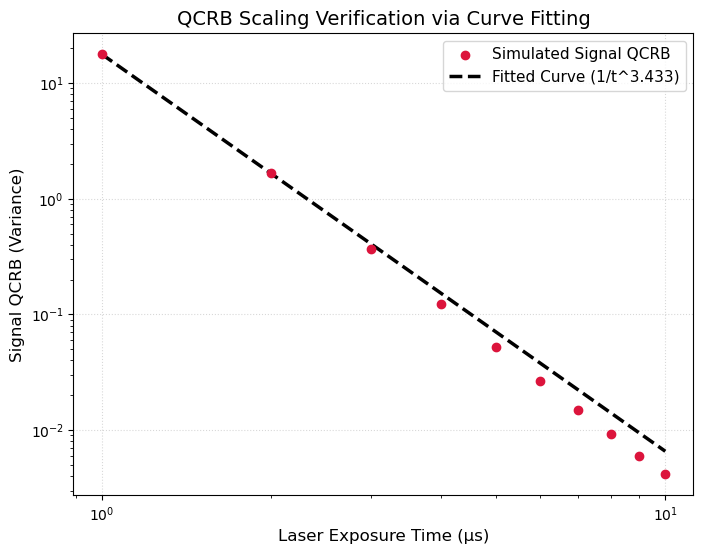

--- Curve Fitting Results ---
Model: f(t) = C / t^n
Estimated Constant (C): 17.7744033377993
Estimated Exponent (n): 3.4333557448681096 (Theoretical expectation is 2.0)
Mean Squared Error (MSE): 0.0003677688486503214


In [ ]:
using PyPlot
using LsqFit
using Statistics

# Extract the raw QCRB displacement data for |0> (Row 1)
qcrb_alpha = qcrb_matrix[1, :]

# Convert displacement QCRB to signal QCRB (which should scale as 1/t^2)
qcrb_signal = qcrb_alpha ./ (time_steps.^2)

# Convert time_steps to a standard array for the fitting function
t_data = collect(time_steps)
y_data = qcrb_signal

model(t, p) = p[1] ./ (t .^ p[2])

# Initial guess: 
# p[1] = the starting value (y_data[1])
# p[2] = 2.0 (our theoretical expectation)
p0 = [y_data[1], 2.0]

# Run the curve fit
fit = curve_fit(model, t_data, y_data, p0)

# Extract the fitted parameters
fitted_constant = fit.param[1]
fitted_exponent = fit.param[2]

# ---------------------------------------------------------
# 3. Calculate the Error (MSE)
# ---------------------------------------------------------
# Calculate the predicted Y values based on our fitted model
y_fit = model(t_data, fit.param)

# Calculate Mean Squared Error (MSE)
mse = mean((y_data .- y_fit).^2)

# Print the definitive mathematical proof to the console
println("--- Curve Fitting Results ---")
println("Model: f(t) = C / t^n")
println("Estimated Constant (C): ", fitted_constant)
println("Estimated Exponent (n): ", fitted_exponent, " (Theoretical expectation is 2.0)")
println("Mean Squared Error (MSE): ", mse)

# ---------------------------------------------------------
# 4. Plot Data vs. Fitted Curve
# ---------------------------------------------------------
fig3 = figure(figsize=(8, 6))

# Plot the raw simulation data as scatter points
PyPlot.scatter(t_data, y_data, color="crimson", label="Simulated Signal QCRB", zorder=3)

# Plot the fitted curve generated by LsqFit
PyPlot.plot(t_data, y_fit, color="black", linestyle="--", linewidth=2.5, label="Fitted Curve (1/t^$(round(fitted_exponent, digits=3)))", zorder=2)

# Formatting
PyPlot.xlabel("Laser Exposure Time (μs)", fontsize=12)
PyPlot.ylabel("Signal QCRB (Variance)", fontsize=12)
PyPlot.title("QCRB Scaling Verification via Curve Fitting", fontsize=14)
PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(color="gray", alpha=0.3, linestyle=":")

# Log scale makes power laws visually linear and easy to inspect
PyPlot.yscale("log")
PyPlot.xscale("log")

display(fig3)